# STIM ON vs OFF Behavioral Analysis
### Digit Span Backwards — LFP + E-Prime
**Run your Session 2 and Session 3 pipeline scripts first, then execute this notebook.**

This notebook assumes your existing pipeline variables are already in memory:
- `trials`, `bslf_rel`, `bslf_mA`, `STIM_THRESHOLD`, `subject`, `session`, `date`

---
### Workflow
1. Run Session 2 pipeline → rename variables → save
2. Run Session 3 pipeline → rename variables → save
3. Execute analysis cells below

## Cell 1 — Imports

In [13]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
from matplotlib.ticker import FuncFormatter, MultipleLocator
from scipy import stats
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline
plt.rcParams.update({
    'font.family':       'sans-serif',
    'font.size':         11,
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'axes.linewidth':    1.1,
    'figure.dpi':        150,
    'savefig.dpi':       180,
    'savefig.bbox':      'tight',
    'savefig.facecolor': 'white',
})

# ── Color constants ────────────────────────────────────────────────────────
C_ON  = '#1A56DB'   # STIM ON  → blue
C_OFF = '#90A4AE'   # STIM OFF → grey
C_S2  = '#E65100'   # Session 2 accent (orange)
C_S3  = '#2E7D32'   # Session 3 accent (green)

print('Imports OK')

Imports OK


## Cell 2 — File Paths (EDIT THESE)

In [14]:
# ── SESSION 2 ─────────────────────────────────────────────────────────────
JSON_PATH_S2   = Path(r"C:\Users\ASSUS\ATN\Digit Span Backwards\Data\Neural Data\DBS ATN DSB Case 1\D. Siragusa\3.5.26\Time stamp 1433\Report_Json_Session_Report_20260305T151703.json")
CSV_PATH_S2    = Path(r"C:\Users\ASSUS\ATN\Digit Span Backwards\Data\Eprime Data\Digit Span Backwards v3.2\DigitSpanBackward v3.3-6-2-Scores.csv")
EVENTS_PATH_S2 = Path(r"C:\Users\ASSUS\ATN\Digit Span Backwards\Session 2\Events.csv")
OUT_DIR_S2     = Path(r"C:\Users\ASSUS\ATN\Digit Span Backwards\Session 2")

# ── SESSION 3 ─────────────────────────────────────────────────────────────
JSON_PATH_S3   = Path(r"C:\Users\ASSUS\ATN\Digit Span Backwards\Data\Neural Data\DBS ATN DSB Case 1\D. Siragusa\3.5.26\Time stamp 1441\Report_Json_Session_Report_20260305T151912.json")
CSV_PATH_S3    = Path(r"C:\Users\ASSUS\ATN\Digit Span Backwards\Data\Eprime Data\Digit Span Backwards v3.2\DigitSpanBackward v3.3-6-3-Scores.csv")
EVENTS_PATH_S3 = Path(r"C:\Users\ASSUS\ATN\Digit Span Backwards\Session 3\Preprocessed Data\Events.csv")
OUT_DIR_S3     = Path(r"C:\Users\ASSUS\ATN\Digit Span Backwards\Session 3")

# ── COMBINED OUTPUT ───────────────────────────────────────────────────────
COMBINED_DIR   = Path(r"C:\Users\ASSUS\ATN\Digit Span Backwards\Session 2 v 3\Combined")
COMBINED_DIR.mkdir(parents=True, exist_ok=True)

STIM_THRESHOLD = 2.0   # mA

print('Paths set.')

Paths set.


## Cell 3 — Pipeline Helper Functions (alignment + trial building)
Reused from your existing v6 script — no changes.

In [15]:
def load_session(json_path, csv_path, events_path, stim_threshold=2.0):
    """
    Full pipeline: load → align → build trials.
    Returns: trials (list of dicts), bslf_rel (np.ndarray), bslf_mA (np.ndarray),
             meta (dict with subject/session/date/offset info)
    """
    # ── Load files ──────────────────────────────────────────────────────────
    with open(json_path) as f:
        report = json.load(f)
    df = pd.read_csv(csv_path,    encoding='utf-8-sig', low_memory=False)
    ev = pd.read_csv(events_path, encoding='utf-8-sig', low_memory=False)

    subject = str(df['Subject'].iloc[0])
    session = str(df['Session'].iloc[0])
    date    = str(df['SessionDate'].iloc[0])

    # ── Alignment anchor: first Left mA 0 → >0 transition ───────────────────
    stim_start_tick = None
    for stream in report['BrainSenseLfp']:
        prev = None
        for pkt in stream['LfpData']:
            curr = pkt['Left']['mA']
            if prev is not None and prev == 0.0 and curr > 0.0:
                stim_start_tick = pkt['TicksInMs']
                break
            prev = curr
        if stim_start_tick is not None:
            break
    assert stim_start_tick, 'ERROR: No 0→>0 mA transition found in BrainSenseLfp!'

    welcome_ms    = int(df['Welcome.TargetOnsetTime'].iloc[0])
    goodbye_ms    = int(df['Goodbye.FinishTime'].iloc[0])
    MANUAL_OFFSET = stim_start_tick - welcome_ms

    def to_rel(eprime_ms):
        return float(eprime_ms) + MANUAL_OFFSET - stim_start_tick

    def tick_to_rel(tick_arr):
        return np.asarray(tick_arr, dtype=float) - stim_start_tick

    # ── Left mA step trace ───────────────────────────────────────────────────
    bslf_tick, bslf_mA = [], []
    for stream in report['BrainSenseLfp']:
        for pkt in stream['LfpData']:
            bslf_tick.append(pkt['TicksInMs'])
            bslf_mA.append(pkt['Left']['mA'])
    bslf_tick = np.array(bslf_tick, dtype=float)
    bslf_mA   = np.array(bslf_mA,  dtype=float)
    bslf_rel  = tick_to_rel(bslf_tick)

    last_stim_idx = int(np.where(bslf_mA > 0)[0][-1])
    last_stim_rel = float(bslf_rel[last_stim_idx])
    session_end_rel = to_rel(goodbye_ms)

    # ── Digit sequences per trial ────────────────────────────────────────────
    digit_rows = df['Digit'].tolist()
    trial_digit_seqs = {}
    offset = 0
    for tn in range(1, 15):
        t_row = ev[(ev['Event_Type'] == 'Main Trial Start') & (ev['Trial_Number'] == tn)]
        if t_row.empty:
            continue
        n = int(t_row.iloc[0]['Num_Digits'])
        trial_digit_seqs[tn] = digit_rows[offset: offset + n]
        offset += n

    # ── Build trial table ────────────────────────────────────────────────────
    def ev_times_all(etype, trial_num):
        rows = ev[(ev['Event_Type'] == etype) & (ev['Trial_Number'] == trial_num)]
        return [float(x) for x in rows['Time_ms'].tolist()]

    def ev_time_first(etype, trial_num):
        vals = ev_times_all(etype, trial_num)
        return vals[0] if vals else None

    trials = []
    for tn in range(1, 15):
        start_row = ev[(ev['Event_Type'] == 'Main Trial Start') & (ev['Trial_Number'] == tn)]
        if start_row.empty:
            continue
        r = start_row.iloc[0]
        t = {
            'num':       tn,
            'digits':    int(r['Num_Digits']) if pd.notna(r['Num_Digits']) else None,
            'acc':       int(r['ACC'])        if pd.notna(r['ACC'])        else None,
            'cresp':     str(int(r['CRESP'])) if pd.notna(r['CRESP'])      else '?',
            'resp':      str(int(r['RESP']))  if pd.notna(r['RESP'])       else '?',
            'digit_seq': trial_digit_seqs.get(tn, []),
        }
        for key, etype in [('start','Main Trial Start'),('end','Main Trial End'),
                            ('cs','Choice Start'),('ce','Choice End'),
                            ('fb_s','Feedback Start'),('fb_e','Feedback End')]:
            ms = ev_time_first(etype, tn)
            t[key] = to_rel(ms) if ms is not None else None
        t['fix_starts']  = [to_rel(ms) for ms in ev_times_all('Fixation Start',  tn)]
        t['fix_ends']    = [to_rel(ms) for ms in ev_times_all('Fixation End',    tn)]
        t['stim_starts'] = [to_rel(ms) for ms in ev_times_all('Stimulus Start',  tn)]
        t['stim_ends']   = [to_rel(ms) for ms in ev_times_all('Stimulus End',    tn)]
        trials.append(t)

    def mA_at(rel_ms):
        idx = int(np.searchsorted(bslf_rel, rel_ms, side='right')) - 1
        return float(bslf_mA[idx]) if idx >= 0 else 0.0

    for i, t in enumerate(trials):
        t['carryover'] = (mA_at(trials[i+1]['start']) >= stim_threshold
                          if i < len(trials) - 1 else False)

    meta = dict(subject=subject, session=session, date=date,
                manual_offset=MANUAL_OFFSET,
                stim_start_tick=stim_start_tick,
                last_stim_rel=last_stim_rel,
                session_end_rel=session_end_rel,
                mA_max=float(bslf_mA.max()))

    print(f'Loaded {subject} | Session {session} | {date} | '
          f'{len(trials)} trials | mA max={meta["mA_max"]:.1f}')
    return trials, bslf_rel, bslf_mA, meta


print('Pipeline helper defined.')

Pipeline helper defined.


## Cell 4 — Analysis Functions

In [16]:
# ─────────────────────────────────────────────────────────────────────────────
# CLASSIFY TRIALS
# Rule: STIM ON if ≥50% of trial window (Main Trial Start → End) has mA ≥ threshold
# Also computes mean_mA, auc (ms·mA), mean_power (mA²) per trial
# ─────────────────────────────────────────────────────────────────────────────
def classify_trials(trials, bslf_rel, bslf_mA, threshold=2.0):
    for t in trials:
        t0, t1 = t['start'], t['end']
        if t0 is None or t1 is None or t1 <= t0:
            t.update(stim_on=False, stim_frac=0.0, mean_mA=0.0, auc=0.0, mean_power=0.0)
            continue
        mask = (bslf_rel >= t0) & (bslf_rel <= t1)
        t_r, t_m = bslf_rel[mask], bslf_mA[mask]
        if len(t_r) < 2:
            t.update(stim_on=False, stim_frac=0.0,
                     mean_mA=float(t_m[0]) if len(t_m) else 0.0,
                     auc=0.0, mean_power=0.0)
            continue
        dt       = np.diff(t_r)
        mid_mA   = (t_m[:-1] + t_m[1:]) / 2.0
        total    = t_r[-1] - t_r[0]
        stim_dur = np.sum(dt[mid_mA >= threshold])
        stim_frac = stim_dur / total if total > 0 else 0.0
        auc       = float(np.trapezoid(t_m, t_r))
        mean_mA   = auc / total if total > 0 else 0.0
        mean_power = float(np.trapezoid(t_m**2, t_r)) / total if total > 0 else 0.0
        t.update(stim_on=stim_frac >= 0.5, stim_frac=float(stim_frac),
                 mean_mA=float(mean_mA), auc=float(auc), mean_power=float(mean_power))
    return trials


# ─────────────────────────────────────────────────────────────────────────────
# COMPUTE METRICS → DataFrame
# ─────────────────────────────────────────────────────────────────────────────
def compute_metrics(trials, label='Session'):
    rows = []
    for t in trials:
        rows.append(dict(
            session=label, trial_num=t['num'], digits=t['digits'],
            acc=t['acc'], stim_on=t.get('stim_on', False),
            stim_frac=t.get('stim_frac', 0.0), mean_mA=t.get('mean_mA', 0.0),
            auc=t.get('auc', 0.0), mean_power=t.get('mean_power', 0.0),
        ))
    df  = pd.DataFrame(rows)
    on  = df[df['stim_on'] == True]
    off = df[df['stim_on'] == False]
    summary = dict(
        n_on=len(on), n_off=len(off),
        correct_on=int(on['acc'].sum()),   correct_off=int(off['acc'].sum()),
        incorrect_on=int((on['acc']==0).sum()), incorrect_off=int((off['acc']==0).sum()),
        acc_on=float(on['acc'].mean())  if len(on)  else np.nan,
        acc_off=float(off['acc'].mean()) if len(off) else np.nan,
    )
    return df, summary


# ─────────────────────────────────────────────────────────────────────────────
# STATISTICAL TESTS
# ─────────────────────────────────────────────────────────────────────────────
def cohens_d(a, b):
    na, nb = len(a), len(b)
    if na < 2 or nb < 2: return np.nan
    pooled = np.sqrt(((na-1)*np.std(a,ddof=1)**2 + (nb-1)*np.std(b,ddof=1)**2) / (na+nb-2))
    return (np.mean(a) - np.mean(b)) / pooled if pooled > 0 else np.nan


def statistical_tests(df):
    """
    Accuracy     → Fisher's Exact (binary, small n)
    Continuous   → Welch's t-test if both groups pass Shapiro-Wilk (p>0.05)
                   else Mann-Whitney U
    Effect sizes → Risk Difference (accuracy) | Cohen's d (continuous)
    """
    on  = df[df['stim_on'] == True]
    off = df[df['stim_on'] == False]
    results = {}

    # Accuracy — Fisher's exact
    if len(on) > 0 and len(off) > 0:
        c_on,  i_on  = int(on['acc'].sum()),  int((on['acc']==0).sum())
        c_off, i_off = int(off['acc'].sum()), int((off['acc']==0).sum())
        _, p = stats.fisher_exact([[c_on, i_on], [c_off, i_off]])
        rd = (c_on/len(on) if len(on) else np.nan) - (c_off/len(off) if len(off) else np.nan)
        results['accuracy'] = dict(p=float(p), effect=rd,
                                   effect_label='Risk Diff (ON−OFF)',
                                   test_name="Fisher's Exact",
                                   groups=(on['acc'].values, off['acc'].values))

    # Continuous metrics
    for metric, elabel in [('mean_mA','Mean Amplitude (mA)'),
                            ('auc','AUC (ms·mA)'),
                            ('mean_power','Mean Power (mA²)')]:
        a = on[metric].dropna().values
        b = off[metric].dropna().values
        if len(a) < 2 or len(b) < 2:
            results[metric] = dict(p=np.nan, effect=np.nan, effect_label="Cohen's d",
                                   test_name='N/A', groups=(a, b))
            continue
        try:
            pa = stats.shapiro(a)[1] if len(a)<=50 else 0.0
            pb = stats.shapiro(b)[1] if len(b)<=50 else 0.0
            normal = (pa > 0.05) and (pb > 0.05)
        except Exception:
            normal = False
        if normal and len(a)>=5 and len(b)>=5:
            stat, p = stats.ttest_ind(a, b, equal_var=False)
            test_name = "Welch's t-test"
        else:
            stat, p = stats.mannwhitneyu(a, b, alternative='two-sided')
            test_name = 'Mann-Whitney U'
        results[metric] = dict(p=float(p), effect=cohens_d(a,b),
                                effect_label="Cohen's d",
                                test_name=test_name, groups=(a, b))
    return results


def print_summary(label, summary, stats_res):
    print(f'\n{"="*65}')
    print(f'  {label}')
    print(f'{"="*65}')
    print(f'  {"Condition":<12} | {"Trials":>6} | {"Correct":>7} | {"Incorrect":>9} | Accuracy')
    print(f'  {"-"*58}')
    print(f'  {"STIM ON":<12} | {summary["n_on"]:>6} | {summary["correct_on"]:>7} | '
          f'{summary["incorrect_on"]:>9} |  {summary["acc_on"]*100:.1f}%')
    print(f'  {"STIM OFF":<12} | {summary["n_off"]:>6} | {summary["correct_off"]:>7} | '
          f'{summary["incorrect_off"]:>9} |  {summary["acc_off"]*100:.1f}%')
    print(f'\n  Statistical Tests:')
    for metric, res in stats_res.items():
        p   = res.get('p', np.nan)
        eff = res.get('effect', np.nan)
        sig = '*** SIGNIFICANT ***' if p < 0.05 else '(ns)'
        eff_s = f'{eff:.3f}' if not np.isnan(eff) else 'N/A'
        print(f'    {metric:<15} | {res["test_name"]:<22} | p={p:.4f} | '
              f'{res["effect_label"]}={eff_s}  {sig}')


print('Analysis functions defined.')

Analysis functions defined.


## Cell 5 — Plotting Functions

In [17]:
def _sig_stars(p):
    if p < 0.001: return '***'
    if p < 0.01:  return '**'
    if p < 0.05:  return '*'
    return 'ns'


def _annotate_bracket(ax, p, effect, effect_label, x0=0, x1=1,
                       y_top=1.08, fontsize=9.5):
    """Draw significance bracket + label above two bars."""
    color = '#D32F2F' if p < 0.05 else '#757575'
    trans = ax.get_xaxis_transform()
    ax.plot([x0, x0, x1, x1], [y_top, y_top+0.03, y_top+0.03, y_top],
            lw=1.4, color=color, transform=trans, clip_on=False)
    eff_s = f'{effect:.2f}' if not np.isnan(effect) else 'N/A'
    ax.text((x0+x1)/2, y_top+0.045,
            f'{_sig_stars(p)}   p={p:.3f}\n{effect_label} = {eff_s}',
            ha='center', va='bottom', fontsize=fontsize, color=color,
            fontweight='bold', transform=trans)


# ─── PLOT 1: Accuracy bar ─────────────────────────────────────────────────
def plot_accuracy_bar(summary, stats_res, label, save_path=None):
    fig, ax = plt.subplots(figsize=(6, 5.5))
    cats   = ['STIM ON', 'STIM OFF']
    accs   = [summary['acc_on']*100, summary['acc_off']*100]
    counts = [(summary['correct_on'],  summary['n_on']),
              (summary['correct_off'], summary['n_off'])]

    bars = ax.bar(cats, accs, color=[C_ON, C_OFF], width=0.45,
                  zorder=3, edgecolor='white', linewidth=1.5)

    for i, (nc, nt) in enumerate(counts):
        if nt > 0:
            p_hat = nc / nt
            se    = np.sqrt(p_hat*(1-p_hat)/nt)*100
            ax.errorbar(i, accs[i], yerr=se, fmt='none',
                        color='#333', capsize=6, lw=2, zorder=4)
        ax.text(i, accs[i]+4,
                f'{nc}/{nt}\n({accs[i]:.0f}%)',
                ha='center', va='bottom', fontsize=10.5, fontweight='bold')

    res = stats_res.get('accuracy', {})
    _annotate_bracket(ax, res.get('p', np.nan), res.get('effect', np.nan),
                      res.get('effect_label', ''), y_top=1.12)

    ax.set_ylim(0, 140)
    ax.set_yticks([0, 25, 50, 75, 100])
    ax.set_ylabel('Accuracy (%)', fontsize=12)
    ax.set_title(f'Accuracy: STIM ON vs STIM OFF\n{label}',
                 fontsize=12, fontweight='bold')
    ax.axhline(50, color='#ccc', lw=1, ls='--', zorder=1)
    ax.yaxis.grid(True, color='#eee', zorder=0); ax.set_axisbelow(True)
    handles = [mpatches.Patch(color=C_ON,  label=f'STIM ON  (n={summary["n_on"]})'),
               mpatches.Patch(color=C_OFF, label=f'STIM OFF (n={summary["n_off"]})')]
    ax.legend(handles=handles, fontsize=9, loc='upper right',
              framealpha=0.9, edgecolor='#ccc')
    fig.tight_layout()
    if save_path: fig.savefig(save_path); print(f'Saved → {save_path}')
    plt.show()


# ─── PLOT 2: Trial-wise strip ─────────────────────────────────────────────
def plot_trial_strip(df, label, save_path=None):
    fig, ax = plt.subplots(figsize=(10, 4))
    rng = np.random.default_rng(42)
    for _, row in df.iterrows():
        color  = C_ON if row['stim_on'] else C_OFF
        marker = 'o'  if row['acc'] == 1 else 'X'
        jit    = rng.uniform(-0.08, 0.08)
        ax.scatter(row['trial_num'], row['acc']+jit, c=color,
                   marker=marker, s=100, zorder=4,
                   edgecolors='white', linewidths=0.8, alpha=0.92)
    ax.set_xlim(0.3, df['trial_num'].max()+0.7)
    ax.set_ylim(-0.4, 1.6)
    ax.set_yticks([0, 1]); ax.set_yticklabels(['Incorrect (0)', 'Correct (1)'])
    ax.set_xticks(sorted(df['trial_num'].unique()))
    ax.set_xlabel('Trial Number', fontsize=11)
    ax.set_title(f'Trial-wise Accuracy by Stimulation State\n{label}',
                 fontsize=12, fontweight='bold')
    ax.grid(True, axis='x', color='#eee', lw=0.8)
    handles = [
        mpatches.Patch(color=C_ON,  label='STIM ON'),
        mpatches.Patch(color=C_OFF, label='STIM OFF'),
        Line2D([0],[0], marker='o', color='w', markerfacecolor='#555', markersize=8, label='Correct'),
        Line2D([0],[0], marker='X', color='w', markerfacecolor='#555', markersize=8, label='Incorrect'),
    ]
    ax.legend(handles=handles, fontsize=9, loc='upper right',
              ncol=2, framealpha=0.9, edgecolor='#ccc')
    fig.tight_layout()
    if save_path: fig.savefig(save_path); print(f'Saved → {save_path}')
    plt.show()


# ─── PLOT 3: Neural metrics (boxplot + swarm) ─────────────────────────────
def plot_neural_metrics(df, stats_res, label, out_dir=None):
    metrics = [
        ('mean_mA',    'Mean Amplitude (mA)', 'mA'),
        ('auc',        'AUC (ms·mA)',          'ms·mA'),
        ('mean_power', 'Mean Power (mA²)',      'mA²'),
    ]
    on  = df[df['stim_on'] == True]
    off = df[df['stim_on'] == False]
    rng = np.random.default_rng(0)

    for metric, title, ylabel in metrics:
        fig, ax = plt.subplots(figsize=(5.5, 5))
        for xi, (grp, color) in enumerate([(on, C_ON), (off, C_OFF)]):
            vals = grp[metric].dropna().values
            if len(vals) == 0: continue
            ax.boxplot(vals, positions=[xi], widths=0.35, patch_artist=True,
                       boxprops=dict(facecolor=color, alpha=0.35, linewidth=1.3),
                       medianprops=dict(color='#111', linewidth=2.2),
                       whiskerprops=dict(linewidth=1.2), capprops=dict(linewidth=1.2),
                       flierprops=dict(marker='o', markerfacecolor=color, markersize=5, alpha=0.5))
            jit = rng.uniform(-0.10, 0.10, len(vals))
            ax.scatter(np.full(len(vals), xi)+jit, vals,
                       c=color, s=60, zorder=5, alpha=0.85,
                       edgecolors='white', linewidths=0.7)

        res  = stats_res.get(metric, {})
        p    = res.get('p', np.nan)
        eff  = res.get('effect', np.nan)
        ymax = df[metric].max()
        if not np.isnan(p) and not np.isnan(ymax):
            gap = abs(ymax) * 0.18
            y1  = ymax + gap
            ax.plot([0,0,1,1],[y1, y1+gap*0.4, y1+gap*0.4, y1],
                    lw=1.3, color='#D32F2F' if p<0.05 else '#757575')
            eff_s = f'  d={eff:.2f}' if not np.isnan(eff) else ''
            ax.text(0.5, y1+gap*0.5,
                    f'{_sig_stars(p)}  p={p:.3f}{eff_s}',
                    ha='center', va='bottom', fontsize=9,
                    color='#D32F2F' if p<0.05 else '#757575', fontweight='bold')
            ax.set_ylim(top=y1+gap*1.8)

        ax.set_xticks([0,1]); ax.set_xticklabels(['STIM ON','STIM OFF'], fontsize=11)
        ax.set_ylabel(ylabel, fontsize=11)
        ax.set_title(f'{title}\n{label}', fontsize=11, fontweight='bold')
        ax.yaxis.grid(True, color='#eee', lw=0.8); ax.set_axisbelow(True)
        ax.text(0.97, 0.01, f'Test: {res.get("test_name","")}',
                ha='right', va='bottom', transform=ax.transAxes,
                fontsize=7.5, color='#888')
        fig.tight_layout()
        if out_dir:
            fname = Path(out_dir) / f'neural_{metric}_{label.replace(" ","")}.png'
            fig.savefig(fname); print(f'Saved → {fname}')
        plt.show()


# ─── PLOT 4: Session comparison (grouped bar) ─────────────────────────────
def plot_session_comparison(sessions_data, save_path=None):
    """
    sessions_data: list of dicts {label, summary}
    """
    fig, ax = plt.subplots(figsize=(7.5, 5.5))
    n_sess = len(sessions_data)
    bw     = 0.32
    xs     = np.arange(n_sess)

    for cond, color, off in [('STIM ON', C_ON, -bw/2), ('STIM OFF', C_OFF, bw/2)]:
        ys, errs, lbls = [], [], []
        for sd in sessions_data:
            s = sd['summary']
            nc = s['correct_on']  if cond=='STIM ON' else s['correct_off']
            nt = s['n_on']        if cond=='STIM ON' else s['n_off']
            acc = nc/nt*100 if nt>0 else 0
            err = np.sqrt(acc/100*(1-acc/100)/nt)*100 if nt>0 else 0
            ys.append(acc); errs.append(err); lbls.append((nc,nt))
        ax.bar(xs+off, ys, width=bw, color=color, label=cond,
               alpha=0.88, edgecolor='white', lw=1.3, zorder=3)
        ax.errorbar(xs+off, ys, yerr=errs, fmt='none',
                    color='#333', capsize=5, lw=1.8, zorder=4)
        for x, y, (nc, nt) in zip(xs+off, ys, lbls):
            ax.text(x, y+2.5, f'{nc}/{nt}', ha='center', va='bottom',
                    fontsize=8.5, fontweight='bold')

    ax.set_xticks(xs)
    ax.set_xticklabels([sd['label'] for sd in sessions_data], fontsize=11)
    ax.set_ylabel('Accuracy (%)', fontsize=12)
    ax.set_ylim(0, 125)
    ax.set_title('Session Comparison: Accuracy by Stimulation State',
                 fontsize=12, fontweight='bold')
    ax.axhline(50, color='#ccc', lw=1, ls='--', zorder=1)
    ax.yaxis.grid(True, color='#eee', zorder=0); ax.set_axisbelow(True)
    ax.legend(fontsize=10, framealpha=0.9, edgecolor='#ccc', loc='upper right')
    fig.tight_layout()
    if save_path: fig.savefig(save_path); print(f'Saved → {save_path}')
    plt.show()


# ─── PLOT 5: Combined strip (both sessions) ───────────────────────────────
def plot_combined_strip(df_all, save_path=None):
    fig, ax = plt.subplots(figsize=(12, 4.5))
    sess_colors = {s: c for s, c in
                   zip(df_all['session'].unique(), [C_S2, C_S3, '#7B1FA2'])}
    rng = np.random.default_rng(7)
    df_all = df_all.copy().reset_index(drop=True)
    df_all['gidx'] = range(1, len(df_all)+1)
    for _, row in df_all.iterrows():
        ec  = sess_colors.get(row['session'], '#555')
        fc  = C_ON if row['stim_on'] else C_OFF
        mk  = 'o'  if row['acc']==1 else 'X'
        jit = rng.uniform(-0.09, 0.09)
        ax.scatter(row['gidx'], row['acc']+jit, c=fc, marker=mk,
                   s=100, edgecolors=ec, linewidths=2.0,
                   zorder=4, alpha=0.88)
    ax.set_ylim(-0.4, 1.65)
    ax.set_yticks([0,1]); ax.set_yticklabels(['Incorrect','Correct'])
    ax.set_xlabel('Global Trial Index (all sessions concatenated)', fontsize=11)
    ax.set_title('Trial-wise Accuracy — Both Sessions\n'
                 '(fill = Stim state, edge colour = Session)',
                 fontsize=12, fontweight='bold')
    ax.grid(True, axis='x', color='#eee', lw=0.8)
    handles = [
        mpatches.Patch(color=C_ON,  label='STIM ON (fill)'),
        mpatches.Patch(color=C_OFF, label='STIM OFF (fill)'),
        Line2D([0],[0], marker='o', color='w', markeredgecolor=C_S2,
               markersize=9, markeredgewidth=2.2, label='Session 2 (edge)'),
        Line2D([0],[0], marker='o', color='w', markeredgecolor=C_S3,
               markersize=9, markeredgewidth=2.2, label='Session 3 (edge)'),
        Line2D([0],[0], marker='o', color='w', markerfacecolor='#555',
               markersize=8, label='Correct'),
        Line2D([0],[0], marker='X', color='w', markerfacecolor='#555',
               markersize=8, label='Incorrect'),
    ]
    ax.legend(handles=handles, fontsize=8.5, loc='upper right',
              ncol=3, framealpha=0.92, edgecolor='#ccc')
    fig.tight_layout()
    if save_path: fig.savefig(save_path); print(f'Saved → {save_path}')
    plt.show()


print('Plotting functions defined.')

Plotting functions defined.


## Cell 6 — Load Session 2

In [18]:
trials_s2, bslf_rel_s2, bslf_mA_s2, meta_s2 = load_session(
    JSON_PATH_S2, CSV_PATH_S2, EVENTS_PATH_S2, STIM_THRESHOLD
)

Loaded 6 | Session 2 | 03-05-2026 | 14 trials | mA max=4.6


## Cell 7 — Load Session 3

In [19]:
trials_s3, bslf_rel_s3, bslf_mA_s3, meta_s3 = load_session(
    JSON_PATH_S3, CSV_PATH_S3, EVENTS_PATH_S3, STIM_THRESHOLD
)

Loaded 6 | Session 3 | 03-05-2026 | 14 trials | mA max=4.7


## Cell 8 — Classify Trials (STIM ON / OFF)

In [20]:
classify_trials(trials_s2, bslf_rel_s2, bslf_mA_s2, STIM_THRESHOLD)
classify_trials(trials_s3, bslf_rel_s3, bslf_mA_s3, STIM_THRESHOLD)

# Quick check
print('Session 2 trial classification:')
for t in trials_s2:
    print(f"  T{t['num']:02d}  stim_on={str(t['stim_on']):<5}  "
          f"stim_frac={t['stim_frac']:.2f}  mean_mA={t['mean_mA']:.2f}  acc={t['acc']}")

print('\nSession 3 trial classification:')
for t in trials_s3:
    print(f"  T{t['num']:02d}  stim_on={str(t['stim_on']):<5}  "
          f"stim_frac={t['stim_frac']:.2f}  mean_mA={t['mean_mA']:.2f}  acc={t['acc']}")

Session 2 trial classification:
  T01  stim_on=False  stim_frac=0.00  mean_mA=0.92  acc=1
  T02  stim_on=False  stim_frac=0.00  mean_mA=1.05  acc=1
  T03  stim_on=False  stim_frac=0.26  mean_mA=1.70  acc=1
  T04  stim_on=False  stim_frac=0.00  mean_mA=0.05  acc=1
  T05  stim_on=False  stim_frac=0.00  mean_mA=0.42  acc=1
  T06  stim_on=False  stim_frac=0.00  mean_mA=1.00  acc=0
  T07  stim_on=True   stim_frac=0.96  mean_mA=2.24  acc=0
  T08  stim_on=True   stim_frac=1.00  mean_mA=3.06  acc=0
  T09  stim_on=True   stim_frac=1.00  mean_mA=3.92  acc=1
  T10  stim_on=True   stim_frac=1.00  mean_mA=4.35  acc=0
  T11  stim_on=True   stim_frac=1.00  mean_mA=4.32  acc=0
  T12  stim_on=True   stim_frac=1.00  mean_mA=4.24  acc=0
  T13  stim_on=True   stim_frac=1.00  mean_mA=4.51  acc=0
  T14  stim_on=True   stim_frac=1.00  mean_mA=4.50  acc=0

Session 3 trial classification:
  T01  stim_on=False  stim_frac=0.00  mean_mA=0.04  acc=1
  T02  stim_on=False  stim_frac=0.00  mean_mA=0.09  acc=1
  T03  

## Cell 9 — Metrics + Stats: Session 2

In [21]:
df_s2, summary_s2 = compute_metrics(trials_s2, label='Session 2')
stats_s2          = statistical_tests(df_s2)
print_summary('Session 2', summary_s2, stats_s2)
df_s2.head(14)


  Session 2
  Condition    | Trials | Correct | Incorrect | Accuracy
  ----------------------------------------------------------
  STIM ON      |      8 |       1 |         7 |  12.5%
  STIM OFF     |      6 |       5 |         1 |  83.3%

  Statistical Tests:
    accuracy        | Fisher's Exact         | p=0.0256 | Risk Diff (ON−OFF)=-0.708  *** SIGNIFICANT ***
    mean_mA         | Mann-Whitney U         | p=0.0007 | Cohen's d=4.195  *** SIGNIFICANT ***
    auc             | Welch's t-test         | p=0.0003 | Cohen's d=2.747  *** SIGNIFICANT ***
    mean_power      | Mann-Whitney U         | p=0.0007 | Cohen's d=3.381  *** SIGNIFICANT ***


,session,trial_num,digits,acc,stim_on,stim_frac,mean_mA,auc,mean_power
0,Session 2,1,2,1,False,0.000000,0.921429,6450.0,0.858571
1,Session 2,2,2,1,False,0.000000,1.050000,6825.0,1.112692
2,Session 2,3,3,1,False,0.263158,1.700000,16150.0,3.300000
3,Session 2,4,3,1,False,0.000000,0.047500,475.0,0.004750
4,Session 2,5,4,1,False,0.000000,0.416667,5000.0,0.387083
5,Session 2,6,4,0,False,0.000000,1.000000,500.0,1.000000
6,Session 2,7,4,0,True,0.960000,2.244000,28050.0,5.108400
7,Session 2,8,4,0,True,1.000000,3.062000,38275.0,9.378600
8,Session 2,9,4,1,True,1.000000,3.923913,45125.0,15.464565
9,Session 2,10,4,0,True,1.000000,4.354348,50075.0,18.980652


## Cell 10 — Metrics + Stats: Session 3

In [22]:
df_s3, summary_s3 = compute_metrics(trials_s3, label='Session 3')
stats_s3          = statistical_tests(df_s3)
print_summary('Session 3', summary_s3, stats_s3)
df_s3.head(14)


  Session 3
  Condition    | Trials | Correct | Incorrect | Accuracy
  ----------------------------------------------------------
  STIM ON      |      2 |       1 |         1 |  50.0%
  STIM OFF     |     12 |       7 |         5 |  58.3%

  Statistical Tests:
    accuracy        | Fisher's Exact         | p=1.0000 | Risk Diff (ON−OFF)=-0.083  (ns)
    mean_mA         | Mann-Whitney U         | p=0.0220 | Cohen's d=2.697  *** SIGNIFICANT ***
    auc             | Mann-Whitney U         | p=0.0220 | Cohen's d=2.569  *** SIGNIFICANT ***
    mean_power      | Mann-Whitney U         | p=0.0220 | Cohen's d=2.680  *** SIGNIFICANT ***


,session,trial_num,digits,acc,stim_on,stim_frac,mean_mA,auc,mean_power
0,Session 3,1,2,1,False,0.000000,0.041667,250.0,0.004167
1,Session 3,2,2,1,False,0.000000,0.089286,625.0,0.012500
2,Session 3,3,3,1,False,0.450000,1.995000,19950.0,9.021500
3,Session 3,4,3,0,False,0.350000,1.452500,14525.0,6.138750
4,Session 3,5,3,0,False,0.000000,0.152174,1750.0,0.025652
5,Session 3,6,3,1,False,0.142857,0.804762,8450.0,2.430000
6,Session 3,7,3,0,True,0.526316,2.310526,21950.0,10.093158
7,Session 3,8,3,1,False,0.150000,0.717500,7175.0,2.501250
8,Session 3,9,3,0,False,0.095238,0.390476,4100.0,1.518095
9,Session 3,10,3,1,True,0.500000,2.252500,22525.0,9.716750


## Cell 11 — Metrics + Stats: Combined

In [23]:
df_all        = pd.concat([df_s2, df_s3], ignore_index=True)
_, summary_all = compute_metrics(trials_s2 + trials_s3, label='Combined')
stats_all      = statistical_tests(df_all)
print_summary('COMBINED (Session 2 + 3)', summary_all, stats_all)


  COMBINED (Session 2 + 3)
  Condition    | Trials | Correct | Incorrect | Accuracy
  ----------------------------------------------------------
  STIM ON      |     10 |       2 |         8 |  20.0%
  STIM OFF     |     18 |      12 |         6 |  66.7%

  Statistical Tests:
    accuracy        | Fisher's Exact         | p=0.0461 | Risk Diff (ON−OFF)=-0.467  *** SIGNIFICANT ***
    mean_mA         | Mann-Whitney U         | p=0.0000 | Cohen's d=3.754  *** SIGNIFICANT ***
    auc             | Mann-Whitney U         | p=0.0000 | Cohen's d=2.890  *** SIGNIFICANT ***
    mean_power      | Mann-Whitney U         | p=0.0000 | Cohen's d=3.293  *** SIGNIFICANT ***


## Cell 12 — Plot 1: Accuracy Bar — Session 2

Saved → C:\Users\ASSUS\ATN\Digit Span Backwards\Session 2\analysis_accuracy_S2.png


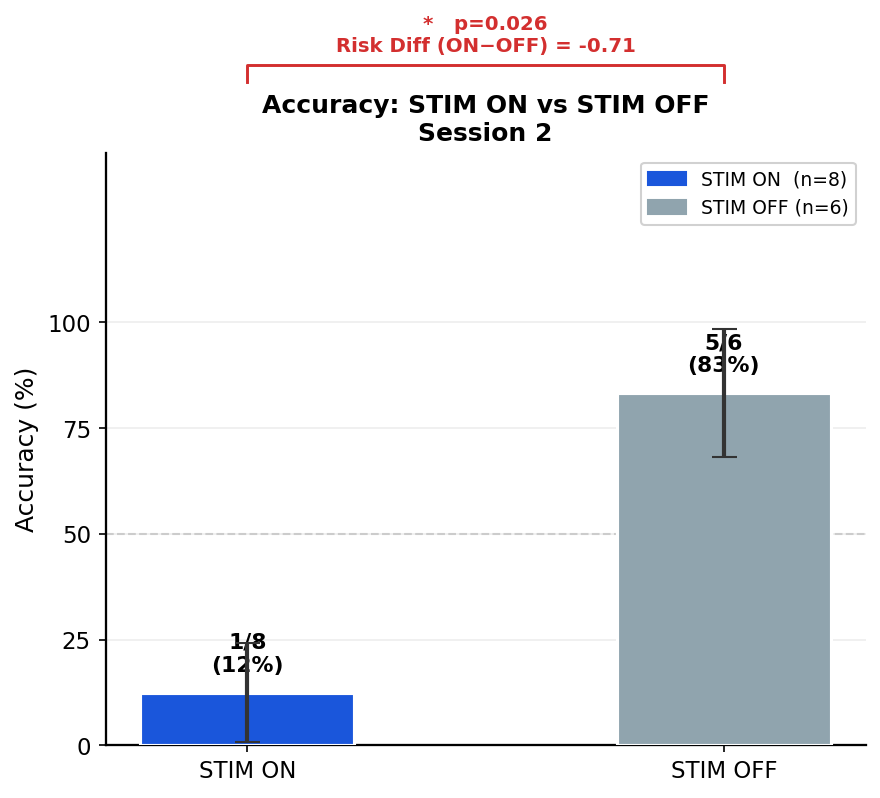

In [24]:
plot_accuracy_bar(summary_s2, stats_s2, 'Session 2',
                  save_path=OUT_DIR_S2 / 'analysis_accuracy_S2.png')

## Cell 13 — Plot 1: Accuracy Bar — Session 3

Saved → C:\Users\ASSUS\ATN\Digit Span Backwards\Session 3\analysis_accuracy_S3.png


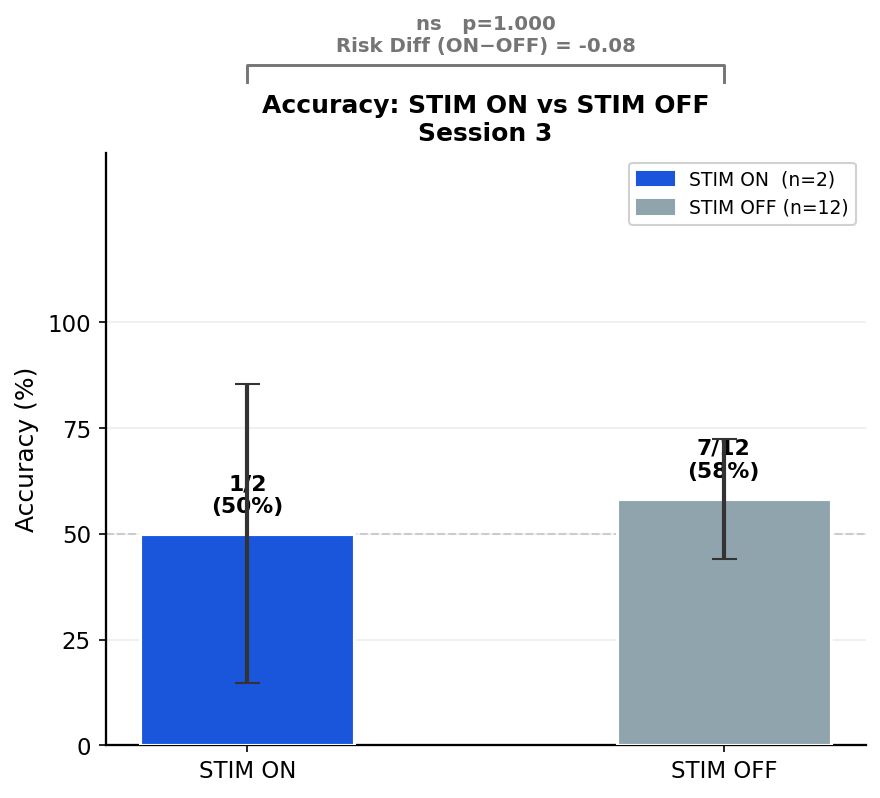

In [25]:
plot_accuracy_bar(summary_s3, stats_s3, 'Session 3',
                  save_path=OUT_DIR_S3 / 'analysis_accuracy_S3.png')

## Cell 14 — Plot 1: Accuracy Bar — Combined

Saved → C:\Users\ASSUS\ATN\Digit Span Backwards\Session 2 v 3\Combined\analysis_accuracy_combined.png


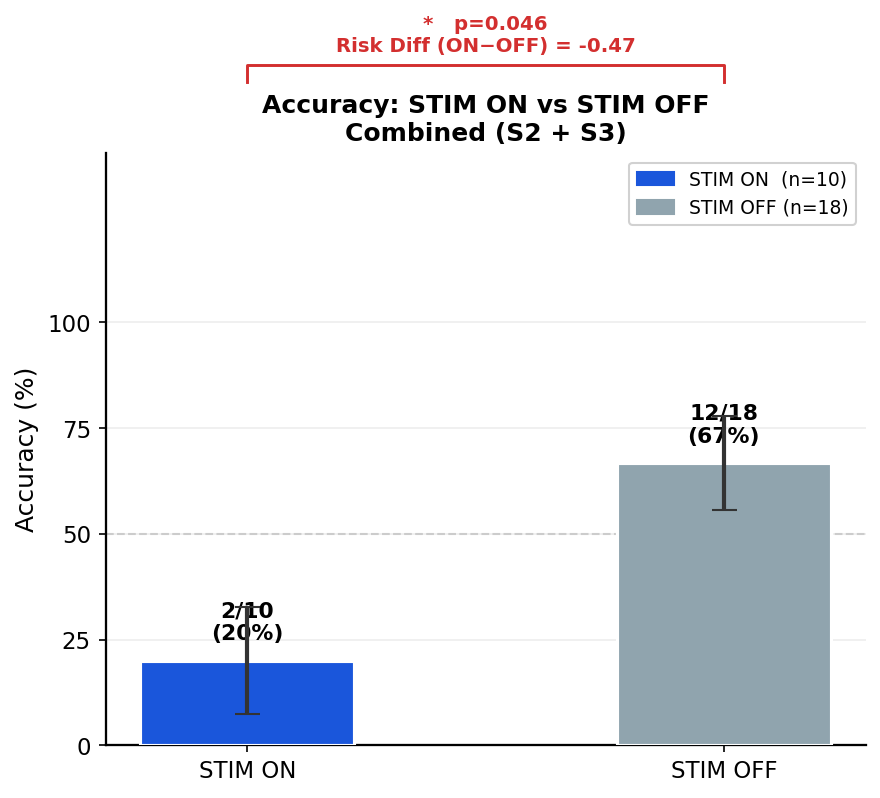

In [26]:
plot_accuracy_bar(summary_all, stats_all, 'Combined (S2 + S3)',
                  save_path=COMBINED_DIR / 'analysis_accuracy_combined.png')

## Cell 15 — Plot 2: Trial Strip — Session 2

Saved → C:\Users\ASSUS\ATN\Digit Span Backwards\Session 2\analysis_strip_S2.png


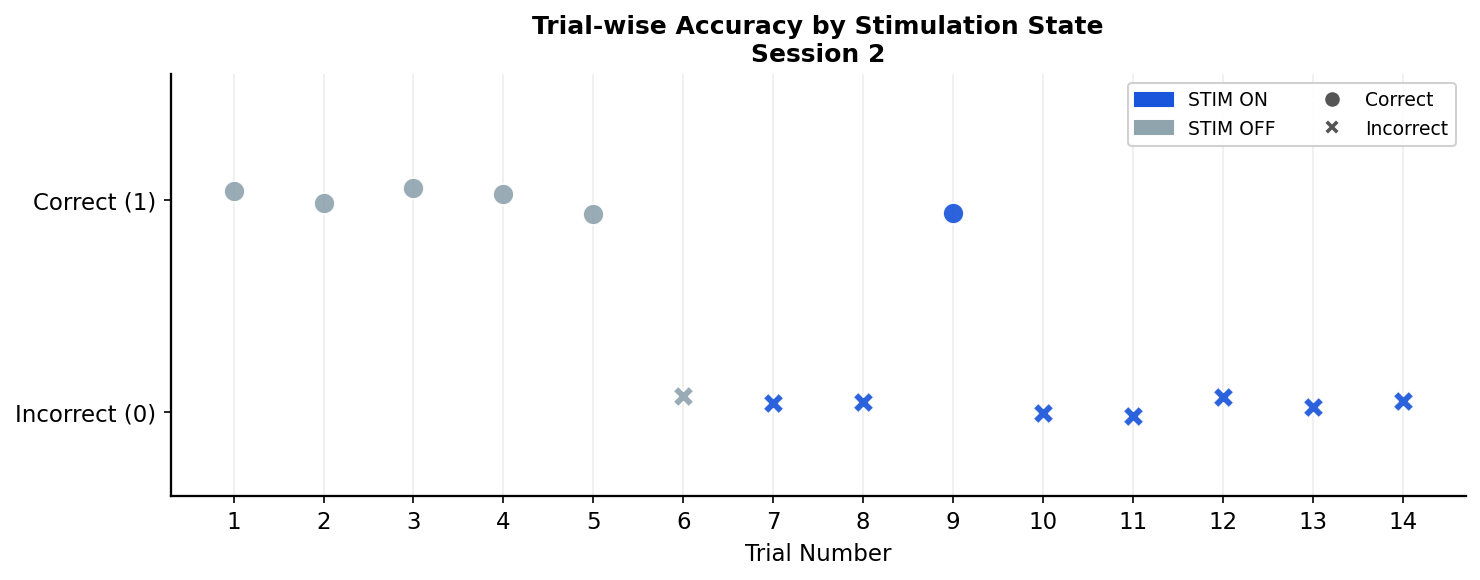

In [27]:
plot_trial_strip(df_s2, 'Session 2',
                 save_path=OUT_DIR_S2 / 'analysis_strip_S2.png')

## Cell 16 — Plot 2: Trial Strip — Session 3

Saved → C:\Users\ASSUS\ATN\Digit Span Backwards\Session 3\analysis_strip_S3.png


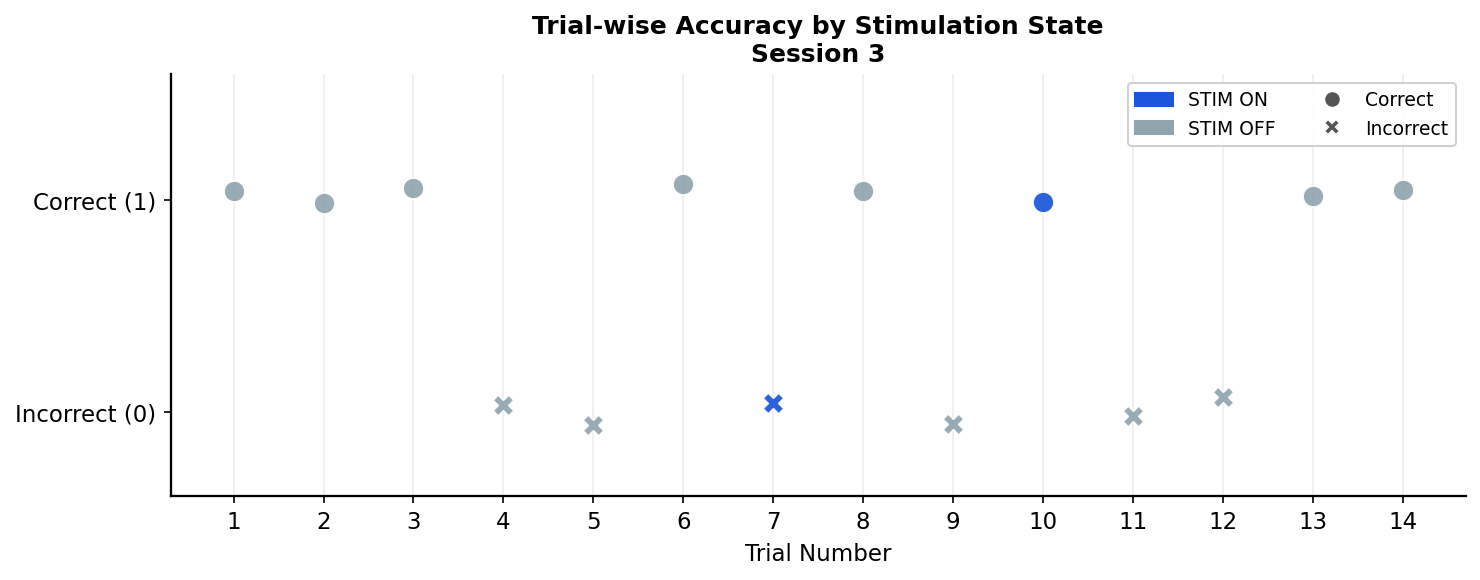

In [28]:
plot_trial_strip(df_s3, 'Session 3',
                 save_path=OUT_DIR_S3 / 'analysis_strip_S3.png')

## Cell 17 — Plot 3: Neural Metrics — Session 2

Saved → C:\Users\ASSUS\ATN\Digit Span Backwards\Session 2\neural_mean_mA_Session2.png


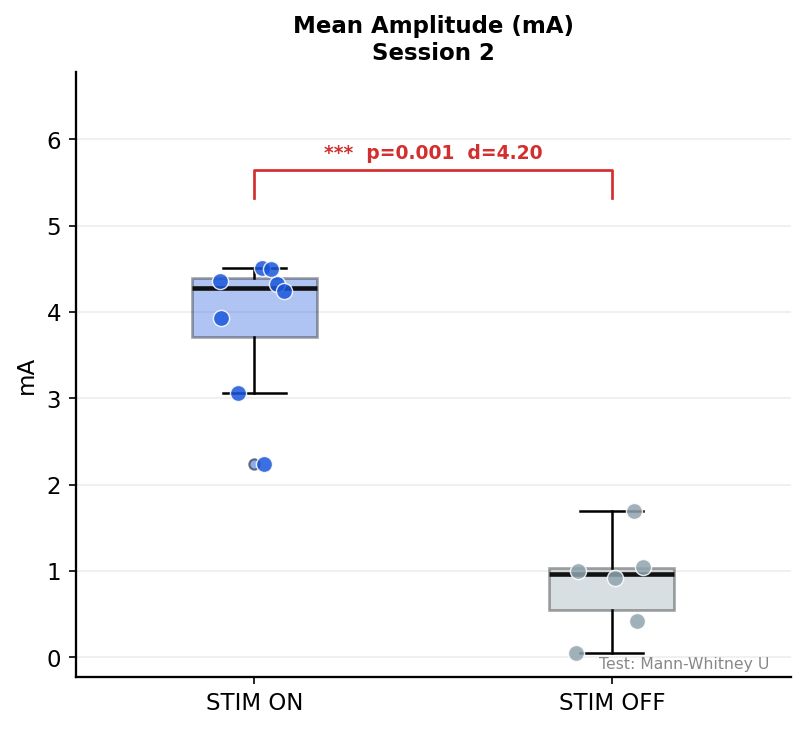

Saved → C:\Users\ASSUS\ATN\Digit Span Backwards\Session 2\neural_auc_Session2.png


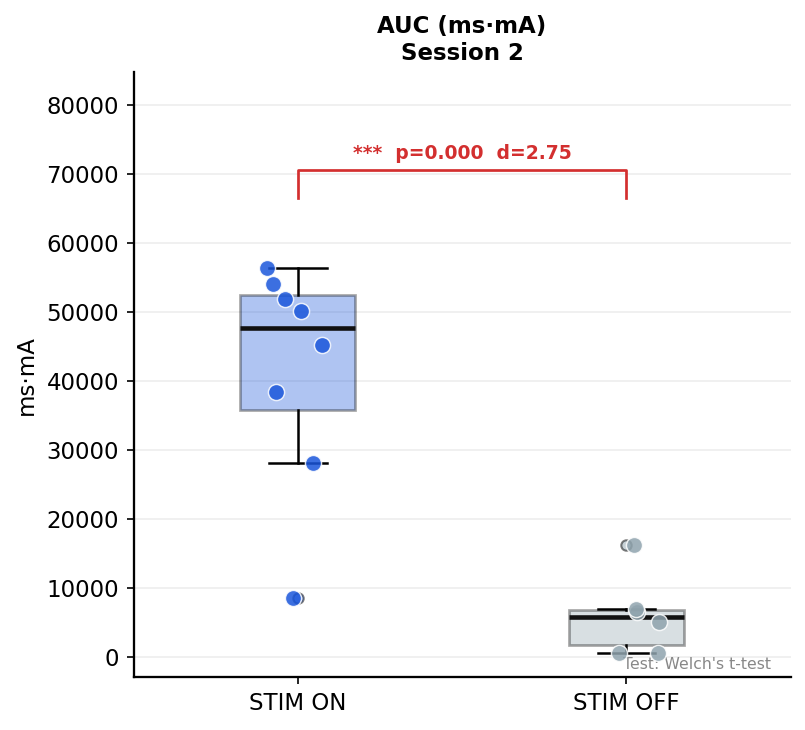

Saved → C:\Users\ASSUS\ATN\Digit Span Backwards\Session 2\neural_mean_power_Session2.png


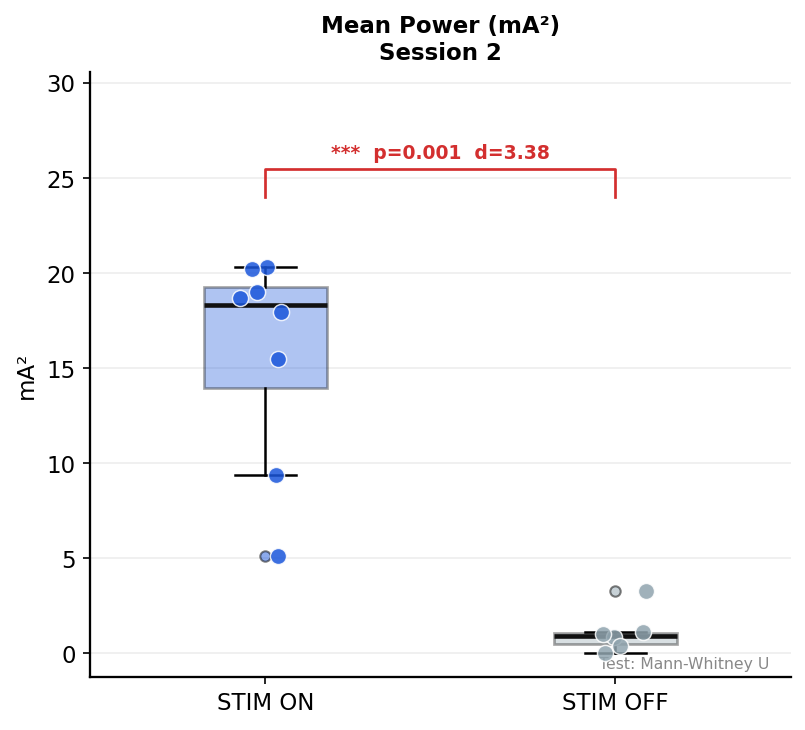

In [29]:
plot_neural_metrics(df_s2, stats_s2, 'Session 2', out_dir=OUT_DIR_S2)

## Cell 18 — Plot 3: Neural Metrics — Session 3

Saved → C:\Users\ASSUS\ATN\Digit Span Backwards\Session 3\neural_mean_mA_Session3.png


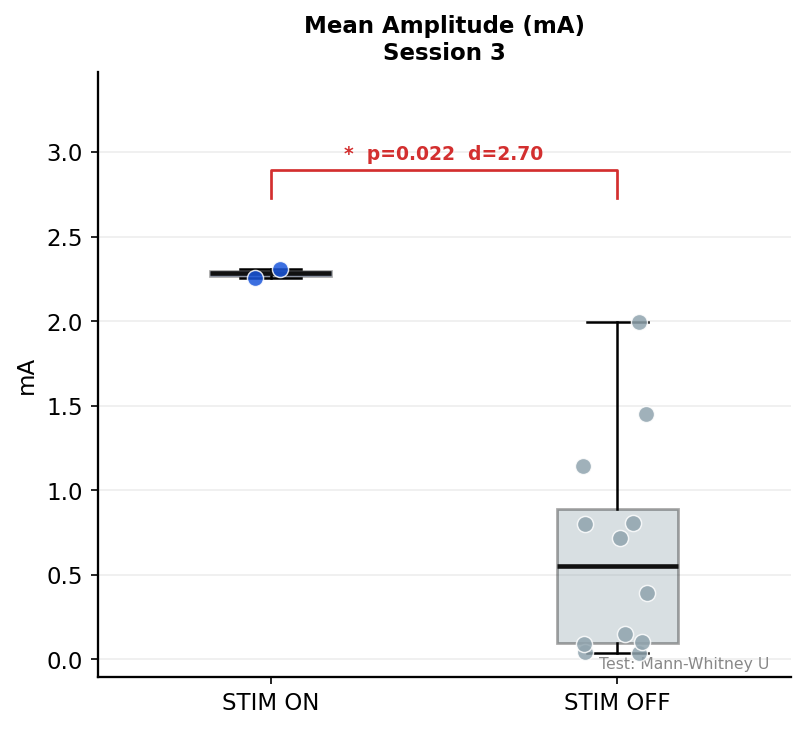

Saved → C:\Users\ASSUS\ATN\Digit Span Backwards\Session 3\neural_auc_Session3.png


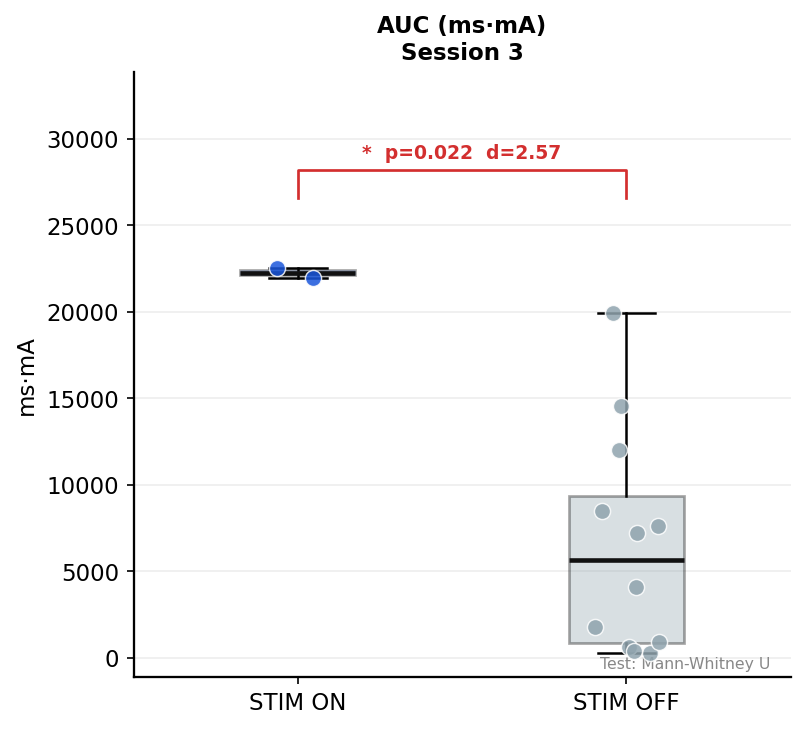

Saved → C:\Users\ASSUS\ATN\Digit Span Backwards\Session 3\neural_mean_power_Session3.png


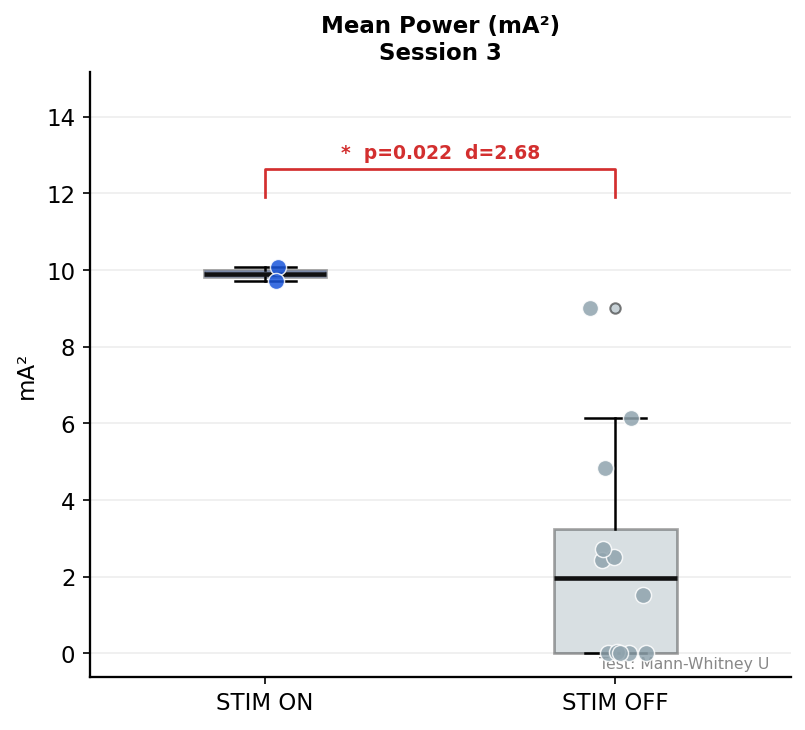

In [30]:
plot_neural_metrics(df_s3, stats_s3, 'Session 3', out_dir=OUT_DIR_S3)

## Cell 19 — Plot 4: Session Comparison

Saved → C:\Users\ASSUS\ATN\Digit Span Backwards\Session 2 v 3\Combined\analysis_session_comparison.png


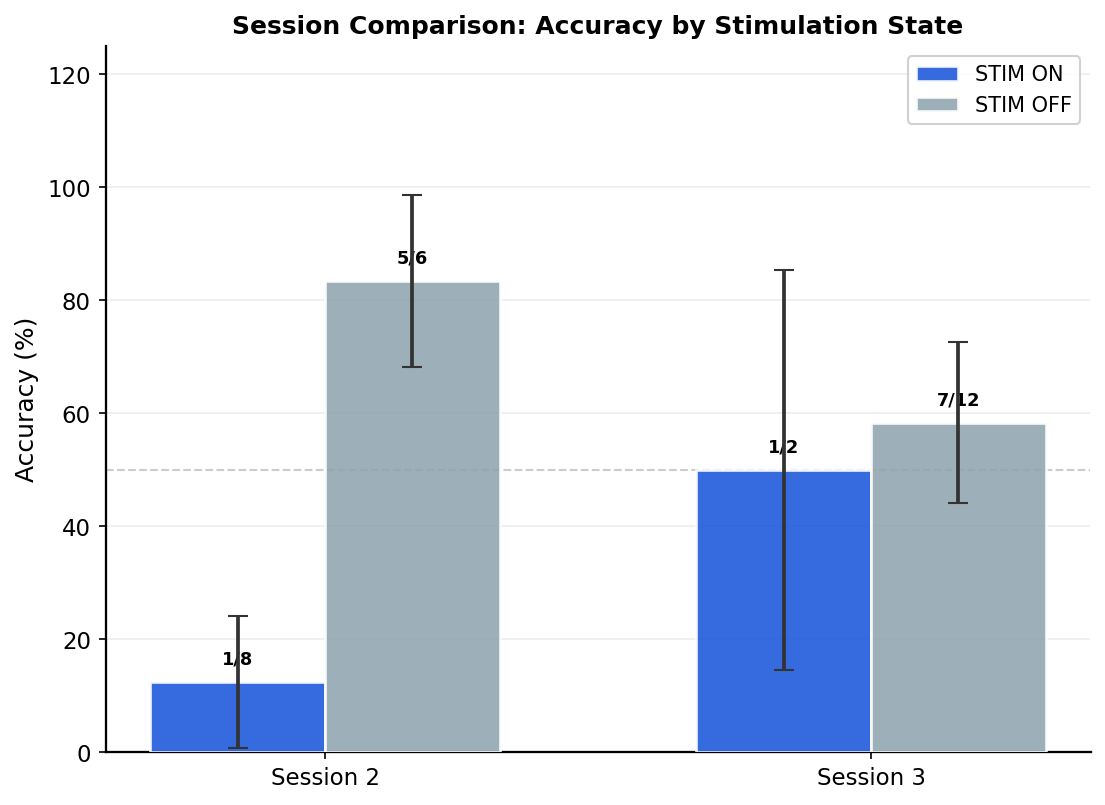

In [31]:
sessions_data = [
    {'label': 'Session 2', 'summary': summary_s2},
    {'label': 'Session 3', 'summary': summary_s3},
]
plot_session_comparison(sessions_data,
                        save_path=COMBINED_DIR / 'analysis_session_comparison.png')

## Cell 20 — Plot 5: Combined Strip (Both Sessions)

Saved → C:\Users\ASSUS\ATN\Digit Span Backwards\Session 2 v 3\Combined\analysis_combined_strip.png


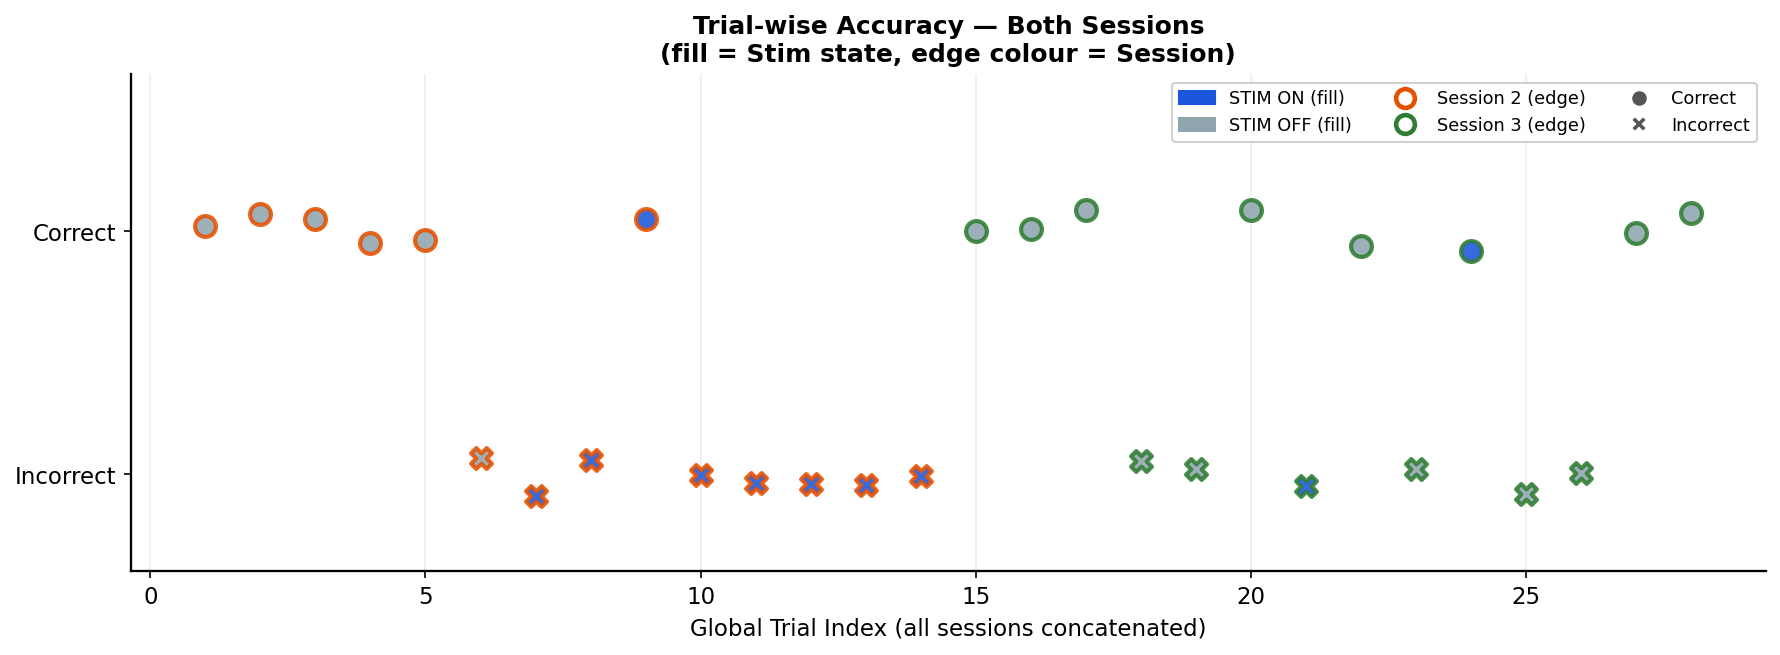

In [32]:
plot_combined_strip(df_all,
                    save_path=COMBINED_DIR / 'analysis_combined_strip.png')

## Cell 21 — Summary Table (all sessions)

In [33]:
rows = []
for sess_label, summary, sres in [
    ('Session 2', summary_s2, stats_s2),
    ('Session 3', summary_s3, stats_s3),
    ('Combined',  summary_all, stats_all),
]:
    p_acc = sres.get('accuracy', {}).get('p', np.nan)
    d_acc = sres.get('accuracy', {}).get('effect', np.nan)
    rows.append(dict(
        Session=sess_label,
        N_StimON=summary['n_on'], N_StimOFF=summary['n_off'],
        Acc_ON=f"{summary['acc_on']*100:.1f}%",
        Acc_OFF=f"{summary['acc_off']*100:.1f}%",
        p_Fisher=f"{p_acc:.4f}" if not np.isnan(p_acc) else 'N/A',
        RiskDiff=f"{d_acc:.3f}" if not np.isnan(d_acc) else 'N/A',
        Significant='Yes' if (not np.isnan(p_acc) and p_acc < 0.05) else 'No',
    ))

summary_table = pd.DataFrame(rows)
display(summary_table)

,Session,N_StimON,N_StimOFF,Acc_ON,Acc_OFF,p_Fisher,RiskDiff,Significant
0,Session 2,8,6,12.5%,83.3%,0.0256,-0.708,Yes
1,Session 3,2,12,50.0%,58.3%,1.0000,-0.083,No
2,Combined,10,18,20.0%,66.7%,0.0461,-0.467,Yes
